In [20]:
import h5py
import numpy as np
import tensorflow as tf

In [21]:
# Load both images and labels directly from the HDF5 file
with h5py.File('all_patches.hdf5', 'r') as f:
    images = f['ct_slices'][:]
    labels = f['slice_class'][:]

# Check the original shapes
print(f"Original Images shape: {images.shape}")
print(f"Original Labels shape: {labels.shape}")

Original Images shape: (6691, 64, 64)
Original Labels shape: (6691, 1)


In [22]:
# Define the new target image size (a recommended size for MobileNetV2)
target_size = (96, 96)

# Resize images and ensure the shape is (num_samples, height, width, 3)
# We expand the grayscale channel to 3 channels by repeating it
images = np.stack([images] * 3, axis=-1)
images = tf.image.resize(images, target_size)

# Normalize pixel values to the range [0, 1]
images = images.numpy().astype('float32') / 255.0

# Reshape labels for the loss function
labels = labels.reshape(-1)

# Check the shapes after preprocessing
print(f"Final Preprocessed Images shape: {images.shape}")
print(f"Final Preprocessed Labels shape: {labels.shape}")

Final Preprocessed Images shape: (6691, 96, 96, 3)
Final Preprocessed Labels shape: (6691,)


In [ ]:
import tensorflow as tf
import keras
from keras.applications import MobileNetV2
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, multiply, Reshape
from keras.regularizers import l2
from keras.models import Model
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import numpy as np

In [24]:
#Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.3, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)
print(f"\nTraining set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")


Training set size: 4683
Validation set size: 1004
Test set size: 1004


In [25]:
# --- NEW FUNCTION: Channel Attention Module ---
def channel_attention(input_feature, ratio=8):
    """
    Implements a Squeeze-and-Excitation (SE) Channel Attention Block.
    """
    channel_axis = -1 
    channel = input_feature.shape[channel_axis]
    
    # Squeeze: Global Average Pooling
    se = GlobalAveragePooling2D()(input_feature)
    
    # Excitation: Two Dense layers
    se = Dense(channel // ratio, activation='relu', use_bias=False)(se)
    se = Dense(channel, activation='sigmoid', use_bias=False)(se)
    
    # 💡 THE FIX: Use the Keras Reshape layer instead of tf.reshape()
    se = Reshape((1, 1, channel))(se) # <-- CORRECTED LINE
    
    # Scale: Apply attention weights
    return multiply([input_feature, se])

In [ ]:
image_size = (X_train.shape[1], X_train.shape[2])
BASE_LEARNING_RATE = 0.001
L2_REG_VALUE = 0.0001

# Load Base MobileNetV2
base_model = MobileNetV2(
    input_shape=(*image_size, 3), 
    include_top=False,
    weights='imagenet'
)

# Freeze the base model layers
base_model.trainable = False 

# Add a Custom Classification Head with Novelty
x = base_model.output

# INSERT CHANNEL ATTENTION MODULE
x = channel_attention(x)

x = GlobalAveragePooling2D()(x)

# ADD L2 REGULARIZATION TO DENSE LAYERS
x = Dense(256, activation='relu', kernel_regularizer=l2(L2_REG_VALUE))(x) 
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid', kernel_regularizer=l2(L2_REG_VALUE))(x) 

# Create the final model
model = Model(inputs=base_model.input, outputs=output)

# Model Compilation
model.compile(
    optimizer=Adam(learning_rate=BASE_LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

print("\nNovel Model compilation complete.")

In [ ]:
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from keras.applications import MobileNetV2
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, multiply, Reshape
from keras.regularizers import l2
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
import os
import matplotlib.pyplot as plt

In [29]:
# --- Callbacks Setup ---
import os
checkpoint_dir = './model_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_filepath = os.path.join(checkpoint_dir, 'best_transfer_model.keras')

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# Save the model with the best validation AUC
model_checkpoint = ModelCheckpoint(
    checkpoint_filepath, 
    monitor='val_auc', 
    mode='max', 
    save_best_only=True
)
callbacks_list = [early_stopping, model_checkpoint]

# --- Execute Initial Training ---
initial_epochs = 20 
BATCH_SIZE = 32

print(f"\nPhase 3.2: Starting initial training ({initial_epochs} epochs) with a FROZEN base model...")

history_transfer = model.fit(
    X_train, y_train,
    epochs=initial_epochs,
    validation_data=(X_val, y_val),
    callbacks=callbacks_list,
    batch_size=BATCH_SIZE
)

print("Initial Transfer Learning Complete.")


Phase 3.2: Starting initial training (20 epochs) with a FROZEN base model...
Epoch 1/20
147/147 [==============================] - 5s 30ms/step - loss: 0.6523 - accuracy: 0.7064 - auc: 0.7391 - val_loss: 0.5693 - val_accuracy: 0.7590 - val_auc: 0.8568
Epoch 2/20
147/147 [==============================] - 3s 21ms/step - loss: 0.4724 - accuracy: 0.7986 - auc: 0.8612 - val_loss: 0.4334 - val_accuracy: 0.8147 - val_auc: 0.8914
Epoch 3/20
147/147 [==============================] - 3s 20ms/step - loss: 0.3725 - accuracy: 0.8490 - auc: 0.9168 - val_loss: 0.3658 - val_accuracy: 0.8436 - val_auc: 0.9211
Epoch 4/20
147/147 [==============================] - 3s 22ms/step - loss: 0.3054 - accuracy: 0.8823 - auc: 0.9475 - val_loss: 0.3775 - val_accuracy: 0.8576 - val_auc: 0.9277
Epoch 5/20
147/147 [==============================] - 3s 21ms/step - loss: 0.2442 - accuracy: 0.9099 - auc: 0.9676 - val_loss: 0.2879 - val_accuracy: 0.8815 - val_auc: 0.9537
Epoch 6/20
147/147 [===========================

In [ ]:
# MEMORY OPTIMIZATION: Clear TensorFlow session before fine-tuning
import gc
from keras import backend as K

# Clear the session to free up memory
K.clear_session()
gc.collect()

print("Memory cleared. Rebuilding model for fine-tuning...")

# Rebuild the model architecture (same as before)
base_model = MobileNetV2(
    input_shape=(*image_size, 3), 
    include_top=False,
    weights='imagenet'
)

# Unfreeze top layers
base_model.trainable = True
fine_tune_at = 120

# Freeze all layers before the fine_tune_at layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
    
# Keep Batch Normalization layers in inference mode (frozen)
for layer in base_model.layers:
    if 'batch_normalization' in layer.name.lower():
        layer.trainable = False

# Rebuild the classification head
x = base_model.output
x = channel_attention(x)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(L2_REG_VALUE))(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid', kernel_regularizer=l2(L2_REG_VALUE))(x)

model = Model(inputs=base_model.input, outputs=output)

# Load the best weights from initial training
model.load_weights(checkpoint_filepath)

# Re-Compile with lower learning rate
FINE_TUNE_LR = BASE_LEARNING_RATE / 100

model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Execute Fine-Tuning
fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs
FINE_TUNE_BATCH_SIZE = 24

print(f"\nPhase 4.3: Starting fine-tuning ({fine_tune_epochs} additional epochs) with UN-FROZEN top layers...")
print(f"Trainable layers: {len([l for l in model.layers if l.trainable])}")
print(f"Fine-tune batch size: {FINE_TUNE_BATCH_SIZE}")

history_fine_tune = model.fit(
    X_train, y_train,
    epochs=total_epochs,
    initial_epoch=len(history_transfer.epoch),
    validation_data=(X_val, y_val),
    callbacks=callbacks_list,
    batch_size=FINE_TUNE_BATCH_SIZE
)

print("Model Fine-Tuning Complete.")

In [31]:
# Load the best weights saved during the training process
model.load_weights(checkpoint_filepath)

# Evaluate on the completely unseen test data
loss, accuracy, auc_score = model.evaluate(X_test, y_test, verbose=1)

print(f"\n--- Final Novel Model Test Set Results ---")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test AUC Score: {auc_score:.4f}")

32/32 [==============================] - 1s 18ms/step - loss: 0.2524 - accuracy: 0.9353 - auc: 0.9732

--- Final Novel Model Test Set Results ---
Test Loss: 0.2524
Test Accuracy: 93.53%
Test AUC Score: 0.9732


In [32]:
final_model_path = 'final_novel_attention_model.keras'

# 3. Save the entire model object
model.save(final_model_path)

print(f"\nFinal model saved successfully to: {final_model_path}")


Final model saved successfully to: final_novel_attention_model.keras


In [33]:
final_model_path = 'final_novel_attention_model.keras'

# Load the model
loaded_model = tf.keras.models.load_model(final_model_path)

# Verify that the model is loaded and ready for prediction
#loaded_model.summary()

# --- Example Usage (Prediction) ---
# Assuming X_new_data is your new input data (e.g., X_test, or production images)

# Predict probabilities
#predictions_proba = loaded_model.predict(X_new_data)

# Convert probabilities to binary class labels (0 or 1)
# Use 0.5 as the threshold for binary classification
#predictions_classes = (predictions_proba > 0.5).astype("int32") 

print("\nModel loaded and ready for prediction.")


Model loaded and ready for prediction.


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Combine the history objects (assuming your history variables are named this way)
def combine_histories(h1, h2):
    """Combines two Keras History objects into a single dictionary."""
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

# Combine the history of the shallow phase and the fine-tuning phase
combined_history = combine_histories(history_transfer, history_fine_tune)

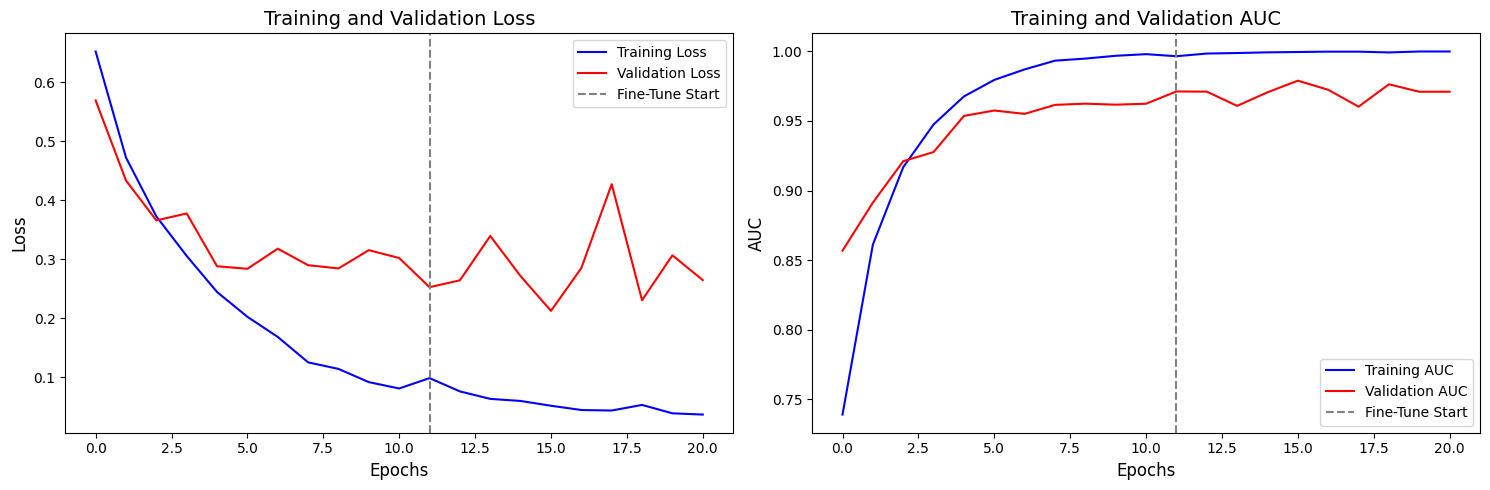

In [35]:
# --- Training History Plotting Function ---
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    epochs = range(len(history['loss']))
    
    # Plot 1: Loss
    ax1.plot(epochs, history['loss'], 'b', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], 'r', label='Validation Loss')
    ax1.set_title('Training and Validation Loss', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.axvline(x=len(history_transfer.epoch), color='gray', linestyle='--', label='Fine-Tune Start')
    ax1.legend()

    # Plot 2: AUC
    ax2.plot(epochs, history['auc'], 'b', label='Training AUC')
    ax2.plot(epochs, history['val_auc'], 'r', label='Validation AUC')
    ax2.set_title('Training and Validation AUC', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('AUC', fontsize=12)
    ax2.axvline(x=len(history_transfer.epoch), color='gray', linestyle='--', label='Fine-Tune Start')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Run the plot
plot_training_history(combined_history)

32/32 [==============================] - 1s 13ms/step


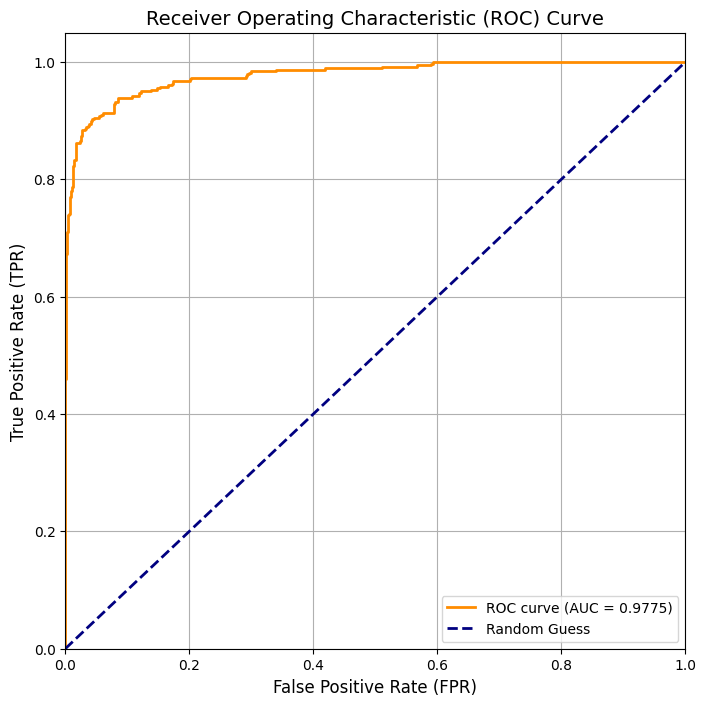

In [36]:
# --- ROC Curve Plot ---

# 1. Generate predictions on the Test Set
# NOTE: Ensure you use the 'model' object with the BEST CHECKPOINT WEIGHTS LOADED!
y_pred_proba = model.predict(X_test).ravel() # Get probability scores

# 2. Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. Get the AUC value (though you already have it from model.evaluate)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

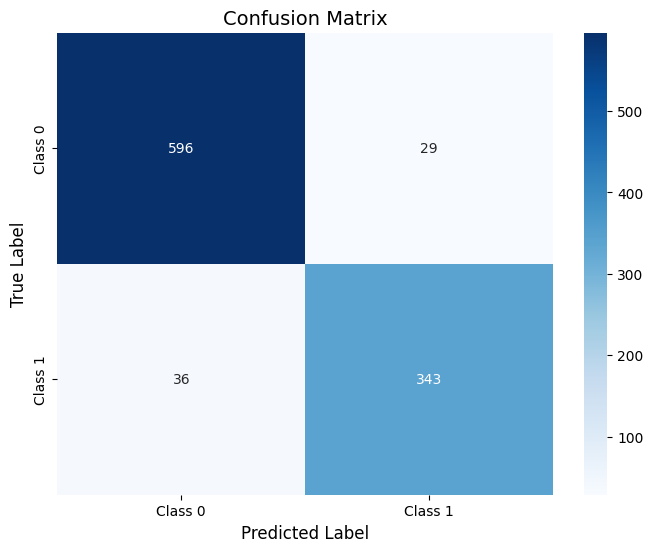


--- Classification Report (for Publication Table) ---
                    precision    recall  f1-score   support

Class 0 (Negative)       0.94      0.95      0.95       625
Class 1 (Positive)       0.92      0.91      0.91       379

          accuracy                           0.94      1004
         macro avg       0.93      0.93      0.93      1004
      weighted avg       0.94      0.94      0.94      1004



In [37]:
# --- Confusion Matrix Plot & Classification Report ---

# 1. Convert probabilities to class predictions (using the standard 0.5 threshold)
y_pred_class = (y_pred_proba > 0.5).astype(int)

# 2. Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)

# 3. Plot the Confusion Matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

# 4. Print the Classification Report
print("\n--- Classification Report (for Publication Table) ---")
print(classification_report(y_test, y_pred_class, target_names=['Class 0 (Negative)', 'Class 1 (Positive)']))